In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from lazypredict.Supervised import LazyClassifier

In [72]:
import warnings
warnings.filterwarnings('ignore')

### section a

In [73]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [76]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [78]:
print(df.isnull().sum().sum())

0


In [79]:
print(df.describe())

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

In [80]:
print(df['target'].value_counts())

target
1    357
0    212
Name: count, dtype: int64


In [81]:
print(df['target'].value_counts(normalize=True) * 100)

target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


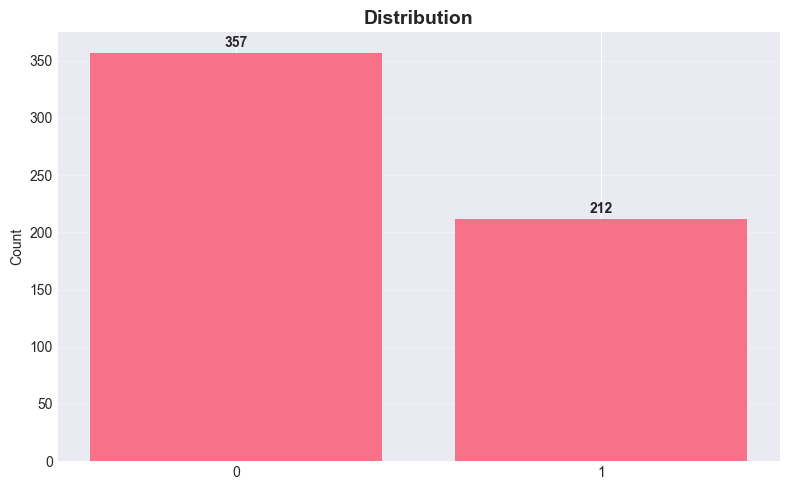

In [87]:
plt.figure(figsize=(8, 5))
counts = df['target'].value_counts()
plt.bar(['0', '1'], counts.values)
plt.title('Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

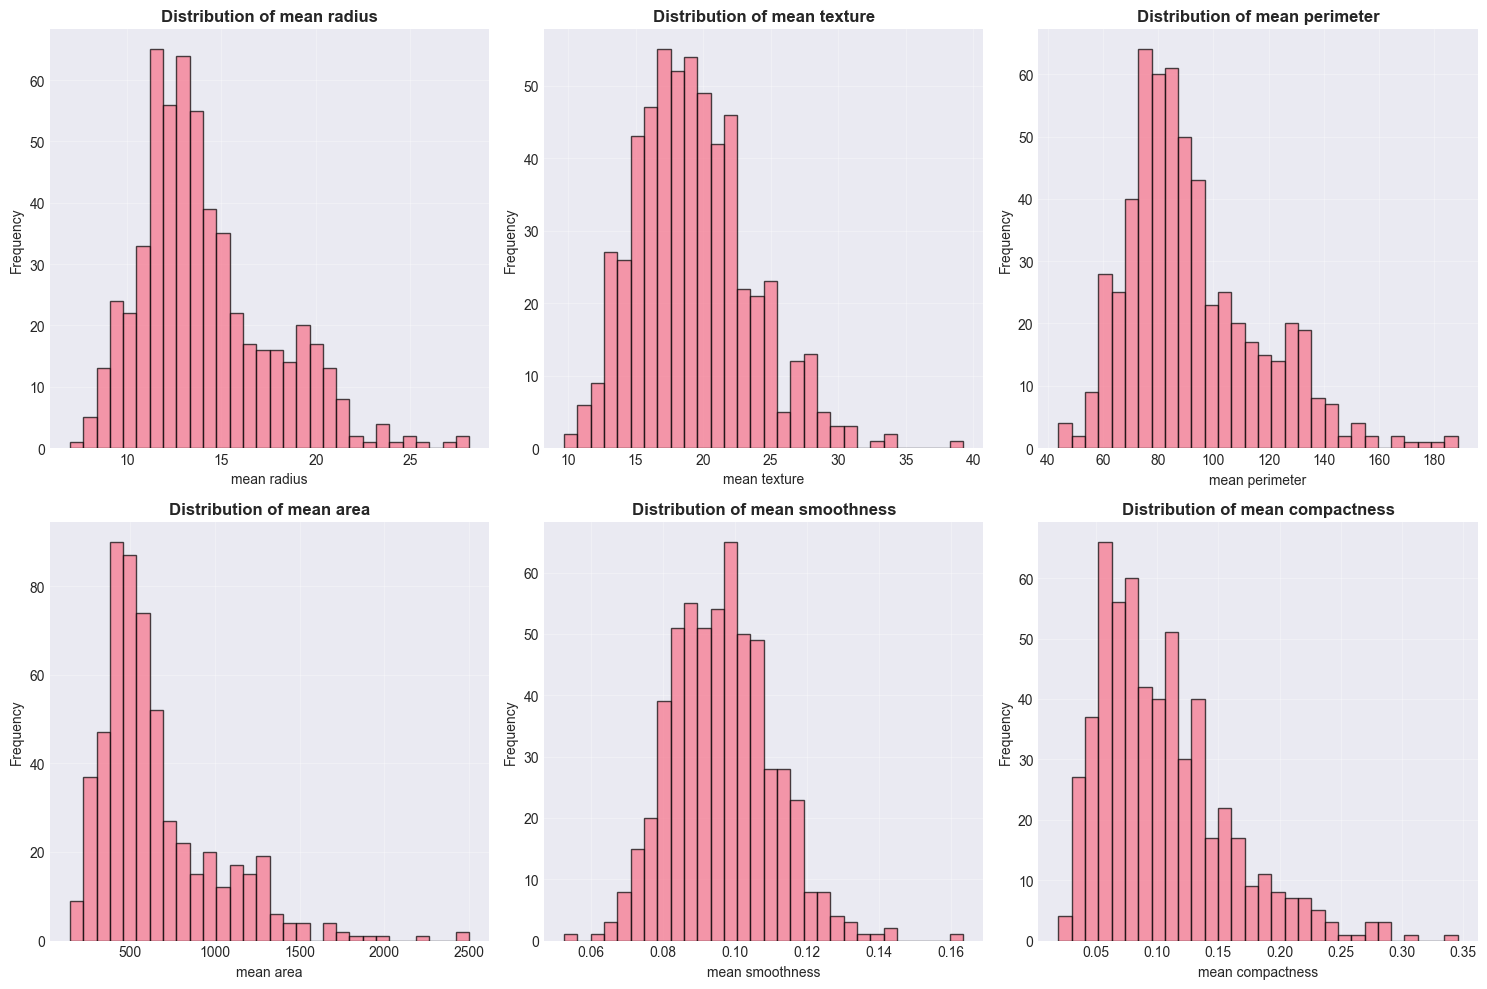

In [88]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 
                    'mean area', 'mean smoothness', 'mean compactness']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df[feature], bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {feature}', fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

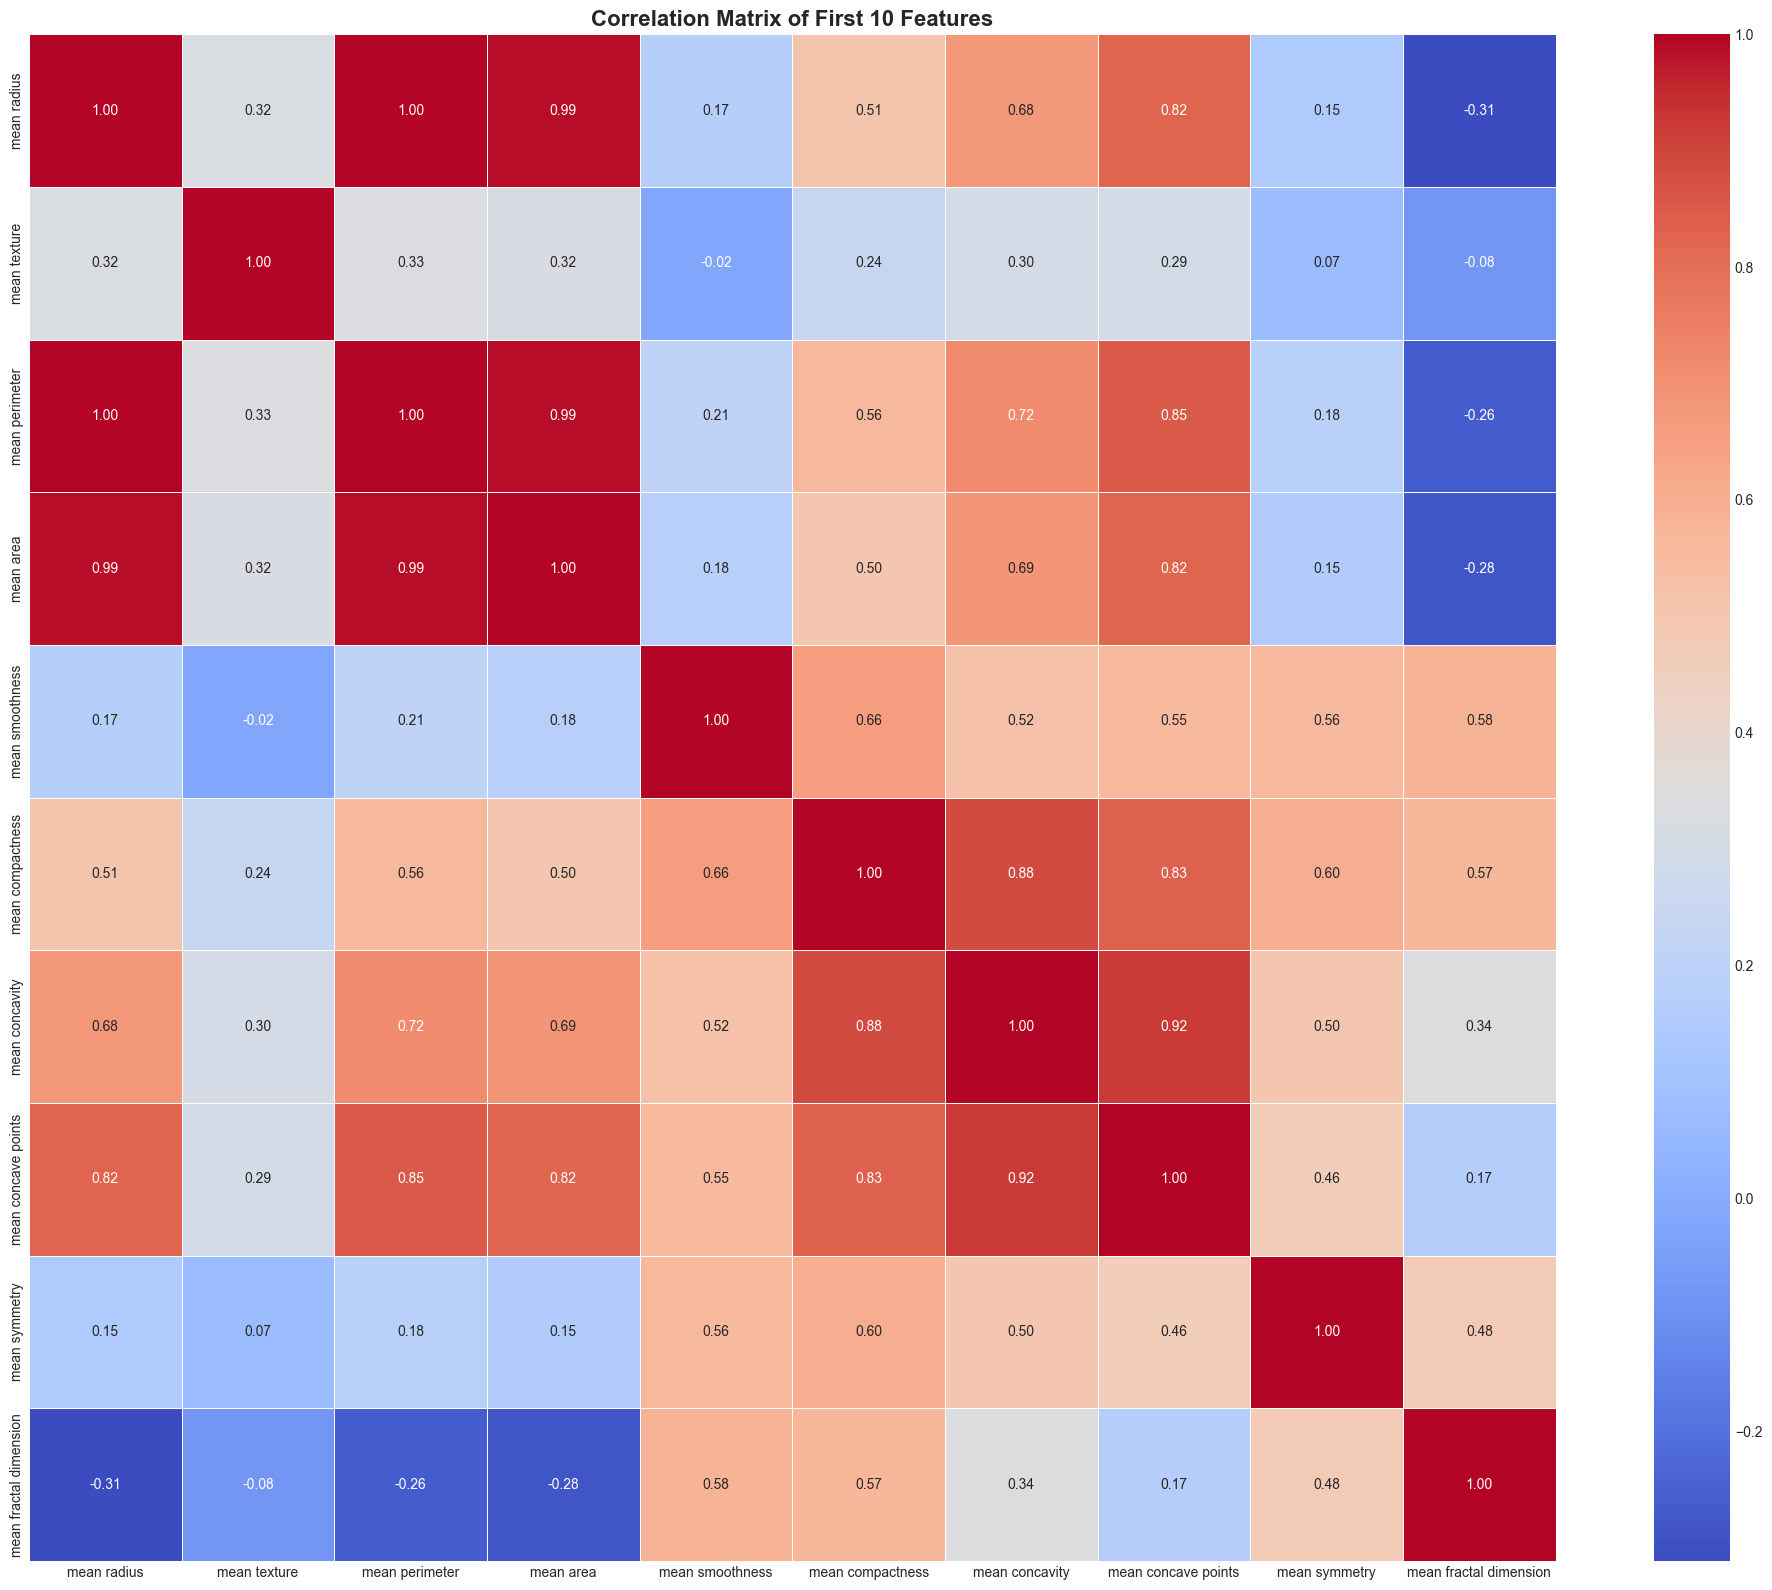

In [89]:
plt.figure(figsize=(20, 16))

correlation_matrix = df.iloc[:, :10].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of First 10 Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### section b

In [ ]:
X = df.drop('target', axis=1)
Y = df['target']

In [92]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [93]:
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [94]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [95]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train_scaled, X_test_scaled, Y_train, Y_test)

In [96]:
print(models)

                             Accuracy  Balanced Accuracy   ROC AUC  F1 Score  \
Model                                                                          
PassiveAggressiveClassifier  0.991228           0.988095  0.994709  0.991205   
LogisticRegression           0.982456           0.981151  0.995370  0.982456   
SVC                          0.982456           0.981151  0.995040  0.982456   
SGDClassifier                0.964912           0.967262  0.994378  0.965073   
CalibratedClassifierCV       0.973684           0.964286  0.993717  0.973465   
LinearSVC                    0.964912           0.962302  0.992725  0.964912   
Perceptron                   0.956140           0.960317  0.994048  0.956430   
ExtraTreesClassifier         0.956140           0.950397  0.992725  0.956027   
KNeighborsClassifier         0.956140           0.950397  0.978836  0.956027   
RandomForestClassifier       0.956140           0.950397  0.993882  0.956027   
LinearDiscriminantAnalysis   0.956140   

In [102]:
top_10_models = models.nlargest(10, 'F1 Score')
print(top_10_models[['Accuracy', 'Precision', 'Recall', 'F1 Score']])

                             Accuracy  Precision    Recall  F1 Score
Model                                                               
PassiveAggressiveClassifier  0.991228   0.991348  0.991228  0.991205
LogisticRegression           0.982456   0.982456  0.982456  0.982456
SVC                          0.982456   0.982456  0.982456  0.982456
CalibratedClassifierCV       0.973684   0.974737  0.973684  0.973465
SGDClassifier                0.964912   0.965858  0.964912  0.965073
LinearSVC                    0.964912   0.964912  0.964912  0.964912
Perceptron                   0.956140   0.958098  0.956140  0.956430
ExtraTreesClassifier         0.956140   0.956073  0.956140  0.956027
KNeighborsClassifier         0.956140   0.956073  0.956140  0.956027
RandomForestClassifier       0.956140   0.956073  0.956140  0.956027


In [100]:
best_model = models['F1 Score'].idxmax()
best_f1 = models.loc[best_model, 'F1 Score']
print(best_model)
print(best_f1)
print(models.loc[best_model, 'Accuracy'])

PassiveAggressiveClassifier
0.9912054752585661
0.9912280701754386


### section c

In [104]:
from sklearn.linear_model import PassiveAggressiveClassifier

In [107]:
pa_model = PassiveAggressiveClassifier(random_state=42)

In [108]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1.0, 10.0, 100.0],
    'max_iter': [100, 500, 1000, 2000, 5000],
    'tol': [1e-5, 1e-4, 1e-3, 1e-2],
    'loss': ['hinge', 'squared_hinge'],
    'fit_intercept': [True, False],
    'early_stopping': [True, False],
    'validation_fraction': [0.1, 0.2, 0.3],
    'n_iter_no_change': [5, 10, 20]
}

In [109]:
random_search = RandomizedSearchCV(
    estimator=pa_model,
    param_distributions=param_grid,
    n_iter=100,  
    cv=5,  
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

In [110]:
random_search.fit(X_train_scaled, Y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",PassiveAggres...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.001, 0.01, ...], 'early_stopping': [True, False], 'fit_intercept': [True, False], 'loss': ['hinge', 'squared_hinge'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... v

In [112]:
print(random_search.best_score_)

0.980715673835183


In [121]:
pa_default = PassiveAggressiveClassifier(random_state=42, max_iter=1000)
pa_default.fit(X_train_scaled, Y_train)
Y_pred_default = pa_default.predict(X_test_scaled)

In [122]:
acc_default = accuracy_score(Y_test, Y_pred_default)
prec_default = precision_score(Y_test, Y_pred_default)
rec_default = recall_score(Y_test, Y_pred_default)
f1_default = f1_score(Y_test, Y_pred_default)

print(acc_default)
print(prec_default)
print(rec_default)
print(f1_default)

0.9912280701754386
0.9863013698630136
1.0
0.993103448275862


In [117]:
best_pa_model = random_search.best_estimator_
Y_pred_tuned = best_pa_model.predict(X_test_scaled)

In [119]:
acc_tuned = accuracy_score(Y_test, Y_pred_tuned)
prec_tuned = precision_score(Y_test, Y_pred_tuned)
rec_tuned = recall_score(Y_test, Y_pred_tuned)
f1_tuned = f1_score(Y_test, Y_pred_tuned)

print(acc_tuned)
print(prec_tuned)
print(rec_tuned)
print(f1_tuned)

0.9912280701754386
0.9863013698630136
1.0
0.993103448275862


### section d

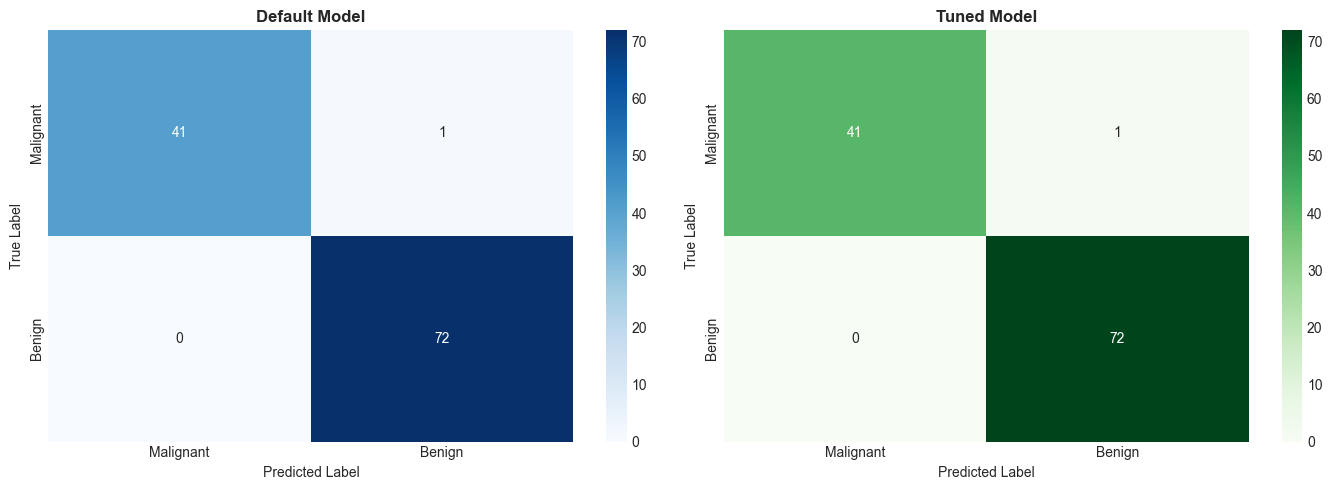

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_default = confusion_matrix(Y_test, Y_pred_default)
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
axes[0].set_title('Default Model', fontweight='bold', fontsize=12)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_tuned = confusion_matrix(Y_test, Y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
axes[1].set_title('Tuned Model', fontweight='bold', fontsize=12)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [129]:
print(classification_report(Y_test, Y_pred_tuned , target_names=['Malignant', 'Benign']))

              precision    recall  f1-score   support

   Malignant       1.00      0.98      0.99        42
      Benign       0.99      1.00      0.99        72

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



<div dir="rtl" align="right">
مزایا و محدودیت‌های ابزارهای خودکار (مثل Lazy Predict):

**مزایا:** این ابزارها برای ساختن یک Baseline در کوتاه‌ترین زمان بسیار مفید هستند. در تحلیل داده‌های پزشکی که زمان تحلیلگر محدود است، Lazy Predict سریع نشان می‌دهد که مسئله بیشتر ماهیت خطی دارد (مثل Logistic Regression) یا غیرخطی (مثل Random Forest).

**محدودیت‌ها:** این ابزارها تا حدی حالت «جعبه سیاه» دارند و معمولاً یک نوع پیش‌پردازش یا Scaling مشابه را برای همه مدل‌ها در نظر می‌گیرند که همیشه بهترین انتخاب نیست. علاوه بر این، در داده‌های پزشکی گاهی مدلی با تفسیرپذیری بالا (مثل Decision Tree) مهم‌تر از صرفاً بیشترین Accuracy است، در حالی که ابزارهای خودکار نمی‌توانند چنین نیازهای بالینی را درک کنند.
</div>


In [130]:
feature_weights = pd.DataFrame({
    'feature': X.columns,
    'weight': best_pa_model.coef_[0]
}).sort_values('weight', ascending=False, key=abs)

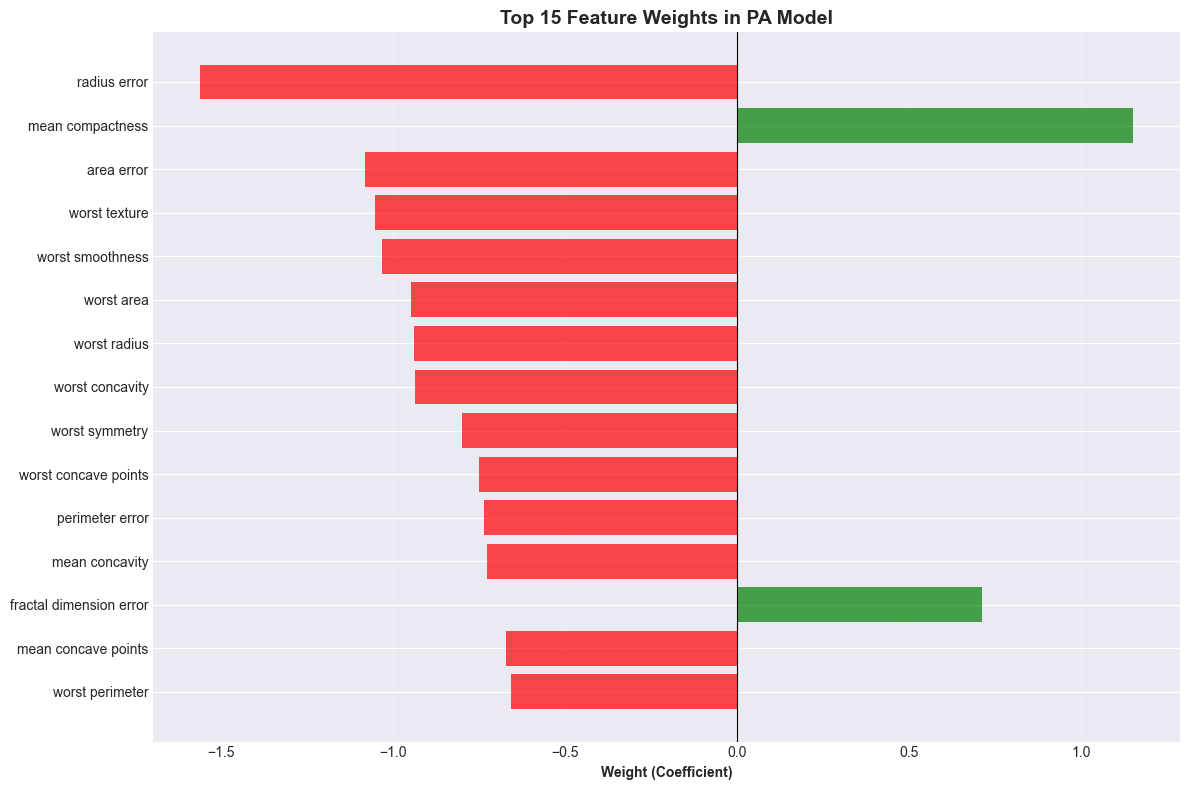

In [132]:
plt.figure(figsize=(12, 8))
top_15_weights = feature_weights.head(15)
colors = ['green' if x > 0 else 'red' for x in top_15_weights['weight']]
plt.barh(range(len(top_15_weights)), top_15_weights['weight'], color=colors, alpha=0.7)
plt.yticks(range(len(top_15_weights)), top_15_weights['feature'])
plt.xlabel('Weight (Coefficient)', fontweight='bold')
plt.title('Top 15 Feature Weights in PA Model', 
          fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()